In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# Load Dataset
# -------------------------------
df = pd.read_csv(
    "Netflix Dataset.csv",
    encoding="latin1",
    low_memory=False
)

sns.set_theme(style="whitegrid")

# Remove duplicates
df.drop_duplicates(inplace=True)

# Fill missing values
df["Director"] = df["Director"].fillna("Unknown")
df["Country"] = df["Country"].fillna("Unknown")
df["Rating"] = df["Rating"].fillna("Not Rated")

# -------------------------------
# Create Movie Dataset
# -------------------------------
movies = df[df["Category"] == "Movie"].copy()

movies["Minutes"] = (
    movies["Duration"]
    .str.extract(r"(\d+)", expand=False)
    .astype(float)
)


Category
Movie      5379
TV Show    2410
Name: count, dtype: int64


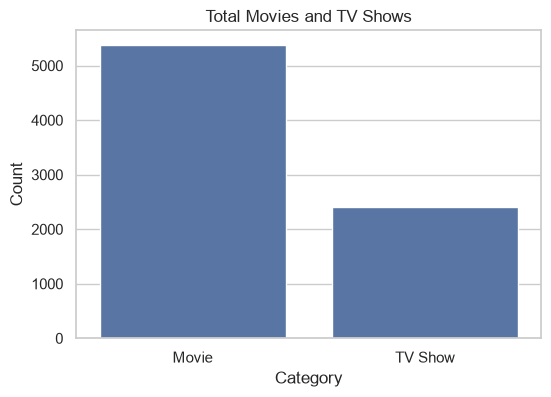

In [37]:
#1	Find the total number of Movies and TV Shows available on Netflix.
category = df["Category"].value_counts()
print(category)
plt.figure(figsize=(6,4))
sns.barplot(x=category.index, y=category.values)
plt.title("Total Movies and TV Shows")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

Category
Movie      69.058929
TV Show    30.941071
Name: proportion, dtype: float64


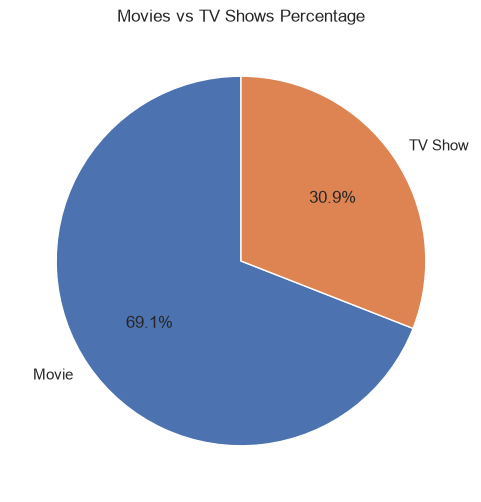

In [9]:
#2	Identify the percentage of Movies vs TV Shows.
category_percent = df["Category"].value_counts(normalize=True) * 100
print(category_percent)
plt.figure(figsize=(6,6))
plt.pie(
    category_percent.values,
    labels=category_percent.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Movies vs TV Shows Percentage")
plt.show()

Country
United States     2556
India              923
United Kingdom     397
Japan              226
South Korea        183
Canada             177
Spain              134
France             115
Egypt              101
Mexico             100
Name: count, dtype: int64


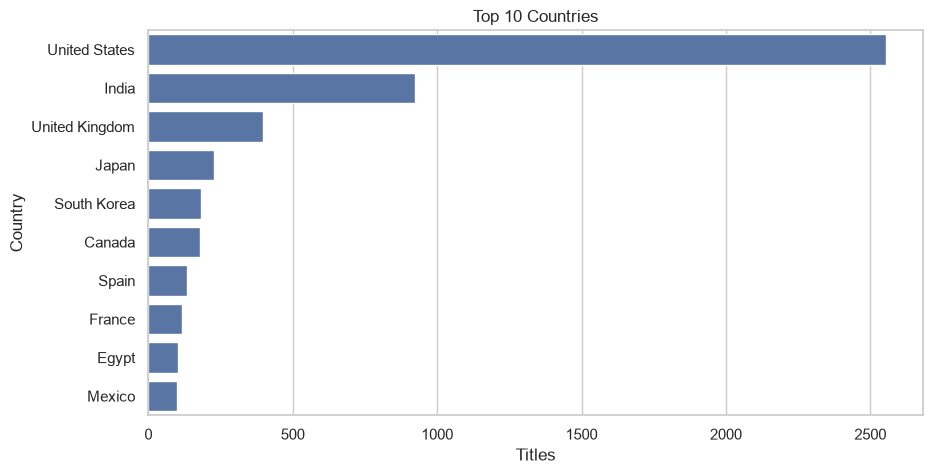

In [10]:
#3	Find the top 10 countries producing Netflix content.
top_country = df["Country"].value_counts().head(10)
print(top_country)
plt.figure(figsize=(10,5))
sns.barplot(x=top_country.values, y=top_country.index)
plt.title("Top 10 Countries")
plt.xlabel("Titles")
plt.ylabel("Country")
plt.show()

Director
RaÃºl Campos, Jan Suter    18
Marcus Raboy               16
Jay Karas                  14
Cathy Garcia-Molina        13
Youssef Chahine            12
Martin Scorsese            12
Jay Chapman                12
Steven Spielberg           10
David Dhawan                9
Kunle Afolayan              8
Name: count, dtype: int64


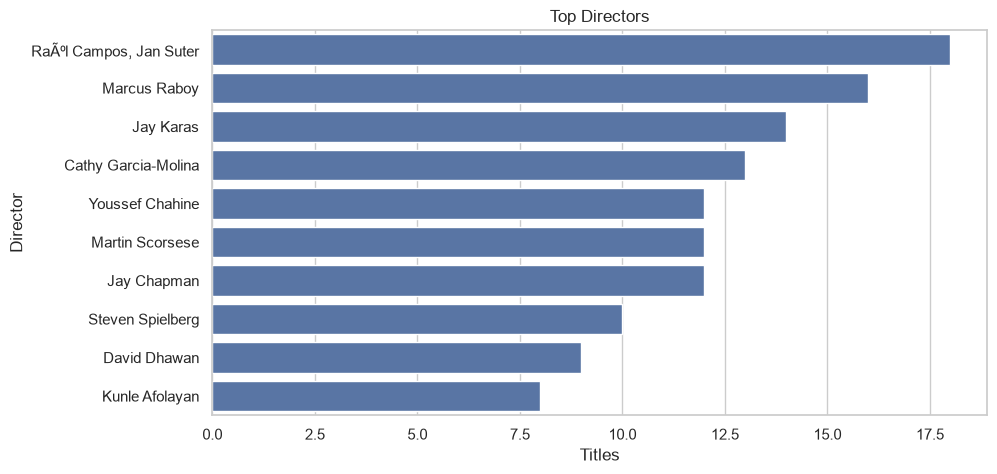

In [11]:
#4	Determine which director has directed the highest number of titles.
top_director = df["Director"].value_counts().head(10)
print(top_director)
plt.figure(figsize=(10,5))
sns.barplot(x=top_director.values, y=top_director.index)
plt.title("Top Directors")
plt.xlabel("Titles")
plt.ylabel("Director")
plt.show()

Rating
TV-MA       2865
TV-14       1931
TV-PG        806
R            665
PG-13        386
TV-Y         280
TV-Y7        271
PG           247
TV-G         194
NR            84
G             39
TV-Y7-FV       6
UR             5
NC-17          3
Name: count, dtype: int64


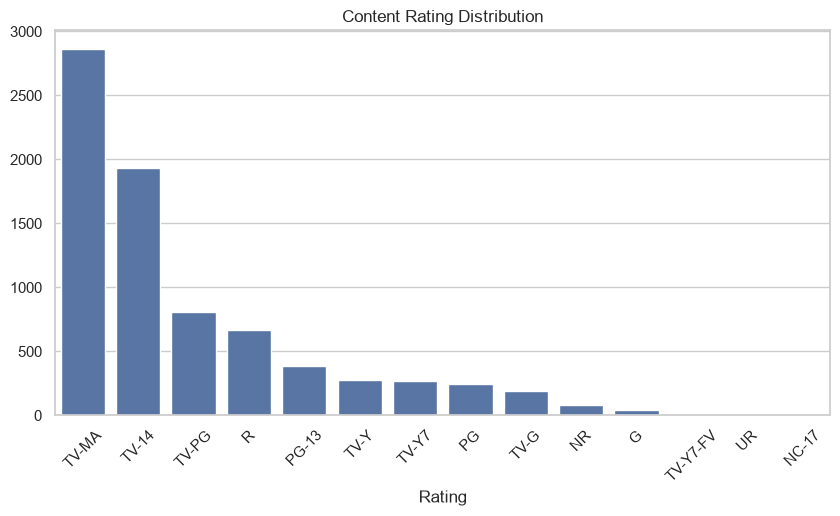

In [12]:
#5	Find the most common content rating.
rating = df["Rating"].value_counts()
print(rating)
plt.figure(figsize=(10,5))
sns.barplot(x=rating.index, y=rating.values)
plt.xticks(rotation=45)
plt.title("Content Rating Distribution")
plt.show()

Release_Date
 April 15, 2018      1
 April 16, 2019      1
 April 17, 2016      1
 April 20, 2017      1
 April 4, 2017       1
                    ..
September 8, 2020    5
September 9, 2016    1
September 9, 2018    1
September 9, 2019    1
September 9, 2020    6
Name: count, Length: 1565, dtype: int64


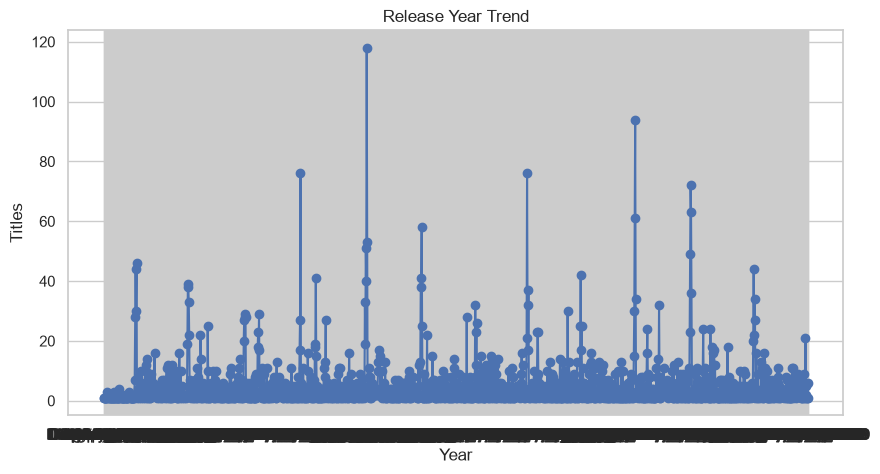

In [14]:
#6	Analyze content released over the years.
release = df["Release_Date"].value_counts().sort_index()
print(release)
plt.figure(figsize=(10,5))
plt.plot(release.index, release.values, marker="o")
plt.title("Release Year Trend")
plt.xlabel("Year")
plt.ylabel("Titles")
plt.show()

Peak Release Year : January 1, 2020
Titles Released : 118


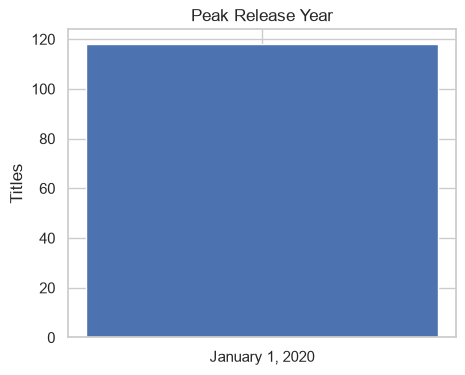

In [15]:
#7	Identify the year with the highest number of releases.
peak_year = release.idxmax()
peak_titles = release.max()
print("Peak Release Year :", peak_year)
print("Titles Released :", peak_titles)
plt.figure(figsize=(5,4))
plt.bar([str(peak_year)], [peak_titles])
plt.title("Peak Release Year")
plt.ylabel("Titles")
plt.show()

In [16]:
#8	Find the longest movie available on Netflix.
movies = df[df["Category"] == "Movie"].copy()
movies["Minutes"] = (
    movies["Duration"]
    .str.extract(r"(\d+)", expand=False)
    .astype(float)
)
longest = movies.loc[movies["Minutes"].idxmax()]
print(longest[["Title","Minutes"]])

Title      Black Mirror: Bandersnatch
Minutes                         312.0
Name: 957, dtype: object


Average Duration : 99.3065625580963


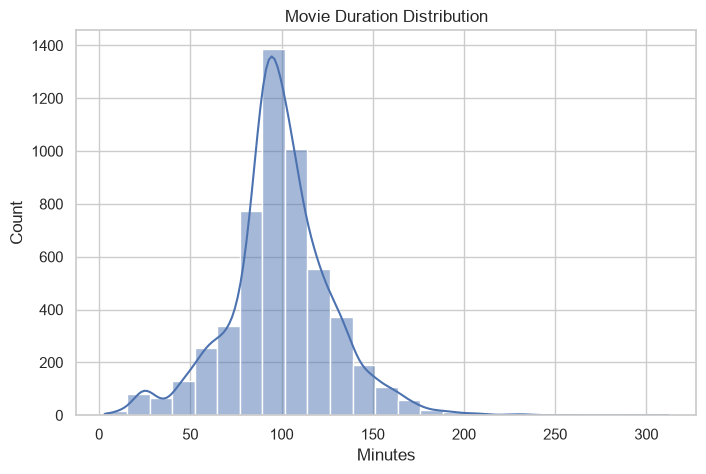

In [17]:
#9	Calculate the average movie duration.
print("Average Duration :", movies["Minutes"].mean())
plt.figure(figsize=(8,5))
sns.histplot(movies["Minutes"], bins=25, kde=True)
plt.title("Movie Duration Distribution")
plt.xlabel("Minutes")
plt.show()

Cast
Anupam Kher         42
Shah Rukh Khan      35
Naseeruddin Shah    30
Om Puri             30
Takahiro Sakurai    29
Akshay Kumar        29
Boman Irani         27
Amitabh Bachchan    27
Paresh Rawal        27
Yuki Kaji           27
Name: count, dtype: int64


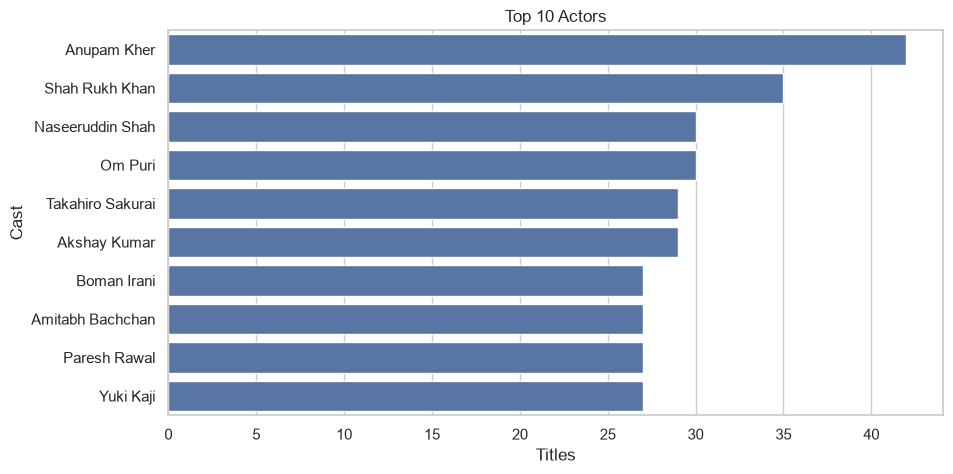

In [18]:
#10	Find the most frequently appearing actor.
actors = (
    df["Cast"]
    .dropna()
    .str.split(",")
    .explode()
    .str.strip()
)
top_actor = actors.value_counts().head(10)
print(top_actor)
plt.figure(figsize=(10,5))
sns.barplot(x=top_actor.values, y=top_actor.index)
plt.title("Top 10 Actors")
plt.xlabel("Titles")
plt.show()

Category  Movie  TV Show
Rating                  
G            39        0
NC-17         3        0
NR           79        5
PG          247        0
PG-13       386        0
R           663        2
TV-14      1272      659
TV-G        111       83
TV-MA      1847     1018
TV-PG       505      301
TV-Y        117      163
TV-Y7        95      176
TV-Y7-FV      5        1
UR            5        0


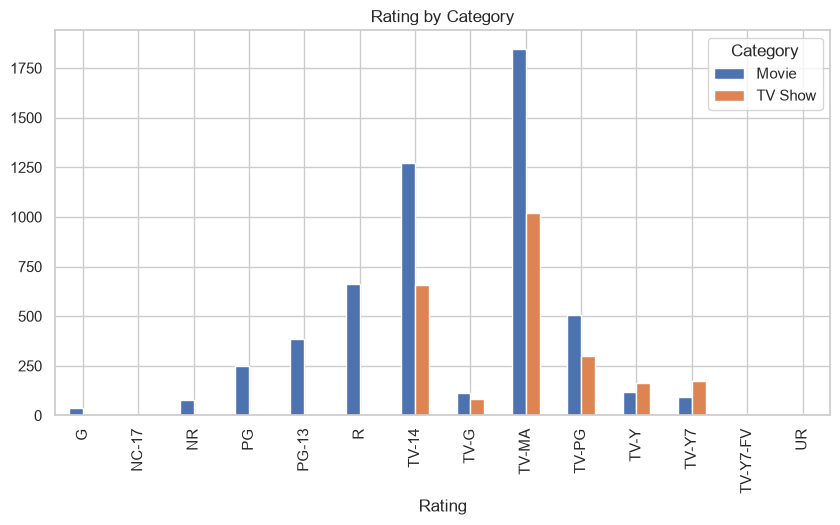

In [19]:
#11	Analyze the distribution of content ratings by category.
rating_category = pd.crosstab(df["Rating"], df["Category"])
print(rating_category)
rating_category.plot(kind="bar", figsize=(10,5))
plt.title("Rating by Category")
plt.show()

Category                                            Movie  TV Show
Country                                                           
Argentina                                              34       16
Argentina, Brazil, France, Poland, Germany, Den...      1        0
Argentina, Chile                                        1        0
Argentina, Chile, Peru                                  1        0
Argentina, France                                       1        0
Argentina, France, United States, Germany, Qatar        1        0
Argentina, Italy                                        1        0
Argentina, Spain                                        7        1
Argentina, United States                                1        0
Argentina, United States, Mexico                        0        1
Argentina, Uruguay, Serbia                              1        0
Argentina, Uruguay, Spain, France                       1        0
Australia                                              37     

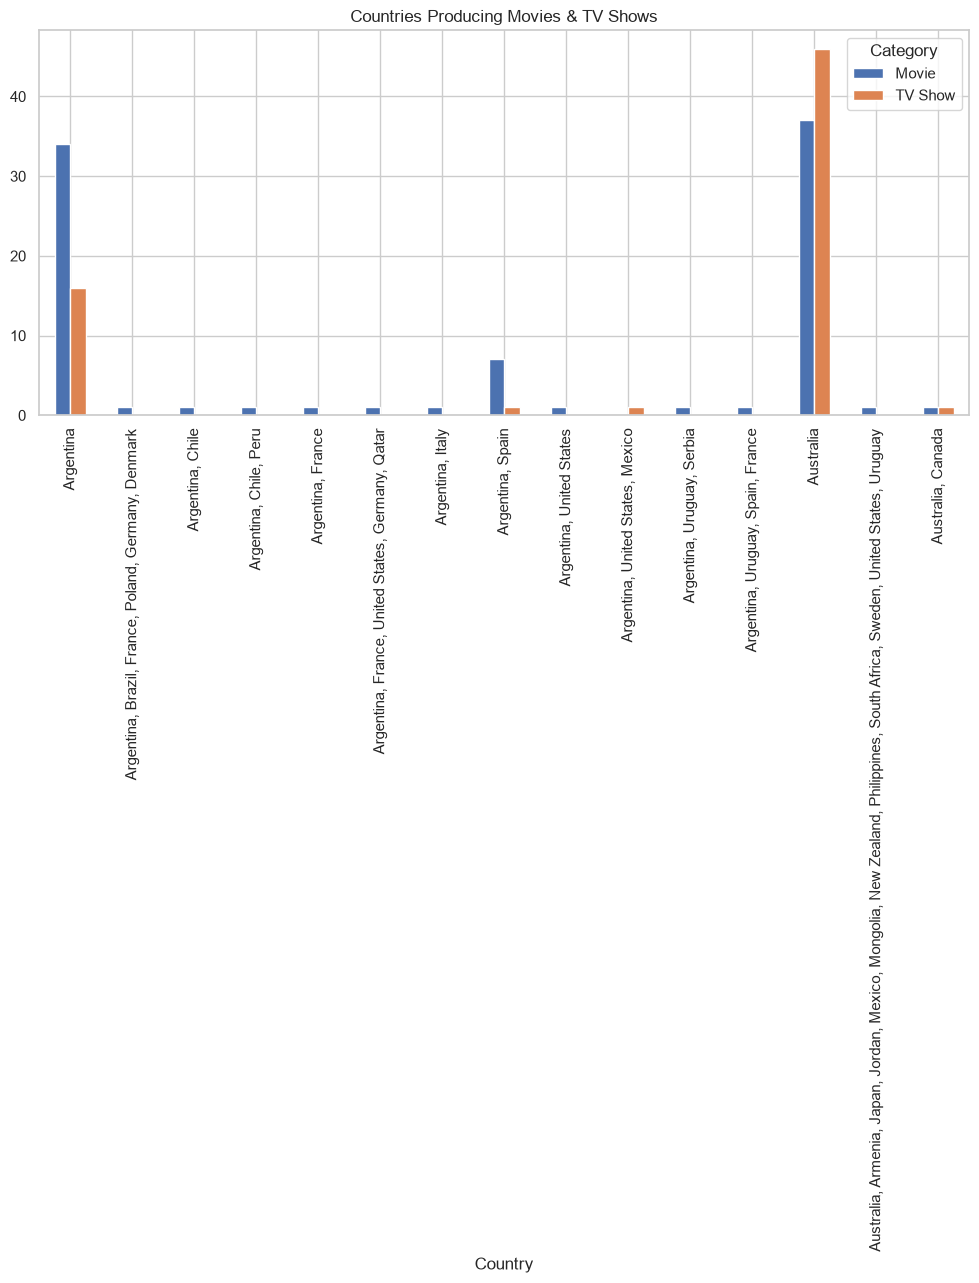

In [20]:
#12	Find the countries producing both Movies and TV Shows.
country_category = pd.crosstab(df["Country"], df["Category"])
print(country_category.head(20))
country_category.head(15).plot(kind="bar", figsize=(12,5))
plt.title("Countries Producing Movies & TV Shows")
plt.show()

Release_Date
December     817
October      780
January      746
November     730
March        661
September    615
August       612
April        597
July         592
June         538
May          537
February     466
Name: count, dtype: int64


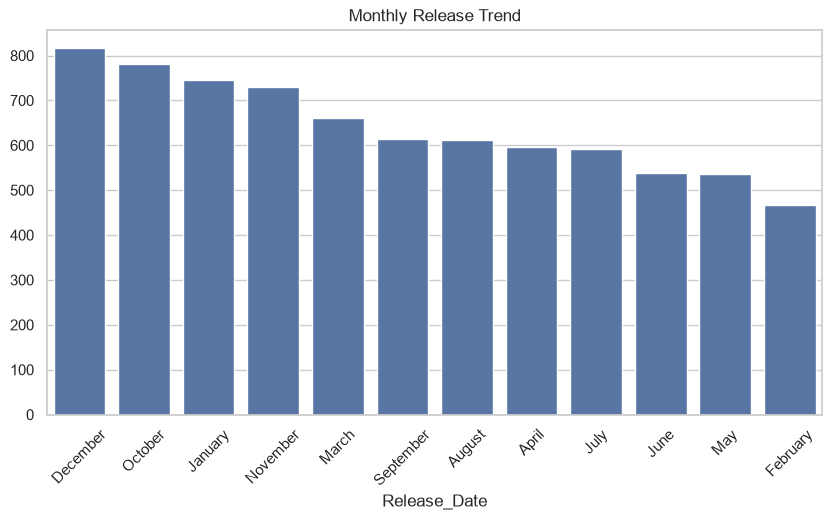

In [21]:
#13	Determine which month has the highest number of releases.
df["Release_Date"] = pd.to_datetime(df["Release_Date"], errors="coerce")
month = df["Release_Date"].dt.month_name().value_counts()
print(month)
plt.figure(figsize=(10,5))
sns.barplot(x=month.index, y=month.values)
plt.xticks(rotation=45)
plt.title("Monthly Release Trend")
plt.show()

Show_Id          0.000000
Category         0.000000
Title            0.000000
Director        30.658621
Cast             9.218128
Country          6.509180
Release_Date     1.258185
Rating           0.089870
Duration         0.000000
Type             0.000000
Description      0.000000
dtype: float64


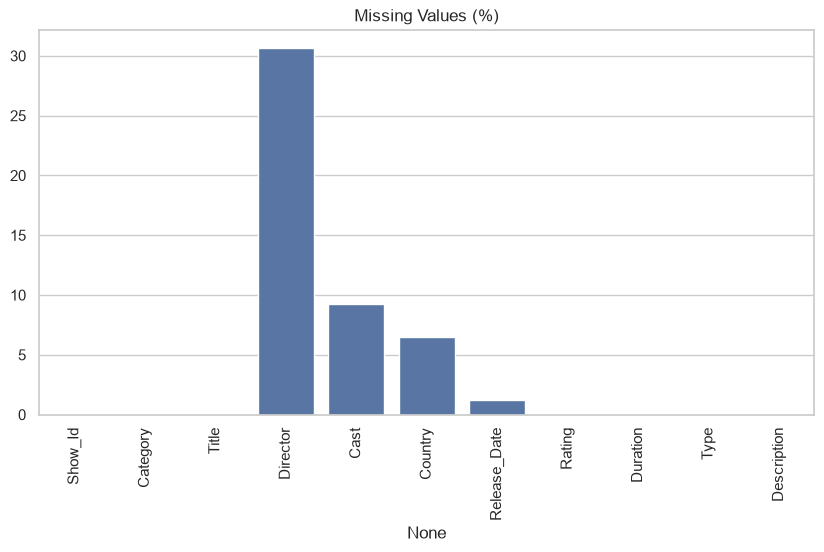

In [22]:
#14	Find the percentage of missing values in each column.
missing = (df.isnull().sum()/len(df))*100
print(missing)
plt.figure(figsize=(10,5))
sns.barplot(x=missing.index, y=missing.values)
plt.xticks(rotation=90)
plt.title("Missing Values (%)")
plt.show()

Category
Movie      5379
TV Show    2410
Name: count, dtype: int64


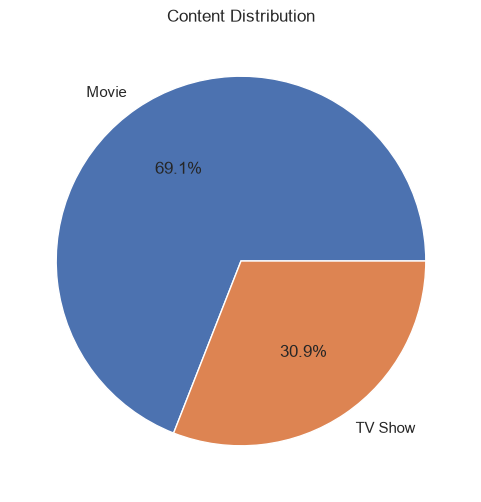

In [23]:
#15	Analyze the distribution of content types.
content = df["Category"].value_counts()
print(content)
plt.figure(figsize=(6,6))
plt.pie(content.values,
        labels=content.index,
        autopct="%1.1f%%")
plt.title("Content Distribution")
plt.show()

Director
RaÃºl Campos, Jan Suter    18
Marcus Raboy               16
Jay Karas                  14
Cathy Garcia-Molina        13
Youssef Chahine            12
Martin Scorsese            12
Jay Chapman                12
Steven Spielberg           10
David Dhawan                9
Kunle Afolayan              8
Hakan AlgÃ¼l                8
Ryan Polito                 8
Shannon Hartman             8
Johnnie To                  8
Lance Bangs                 8
Name: count, dtype: int64


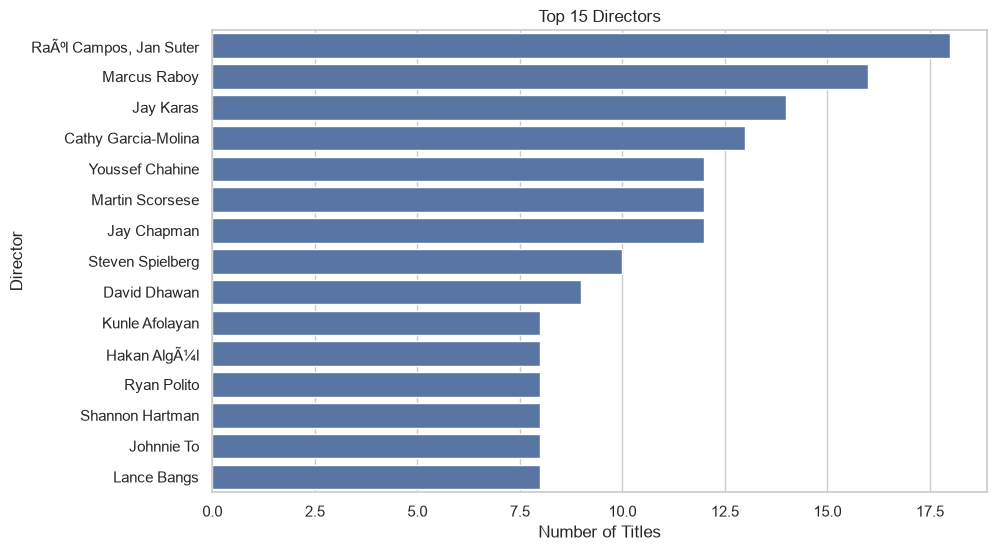

In [24]:
#16	Find the top 15 directors based on the number of titles released.
top15_director = df["Director"].value_counts().head(15)
print(top15_director)
plt.figure(figsize=(10,6))
sns.barplot(
    x=top15_director.values,
    y=top15_director.index
)
plt.title("Top 15 Directors")
plt.xlabel("Number of Titles")
plt.ylabel("Director")
plt.show()

Rating                                              G  NC-17  NR  PG  PG-13  \
Country                                                                       
Argentina                                           0      0   2   0      0   
Argentina, Brazil, France, Poland, Germany, Den...  0      0   0   0      0   
Argentina, Chile                                    0      0   0   0      0   
Argentina, Chile, Peru                              0      0   0   0      0   
Argentina, France                                   0      0   0   0      0   
...                                                ..    ...  ..  ..    ...   
Venezuela                                           0      0   0   0      0   
Venezuela, Colombia                                 0      0   1   0      0   
Vietnam                                             0      0   0   0      0   
West Germany                                        0      0   0   0      0   
Zimbabwe                                            

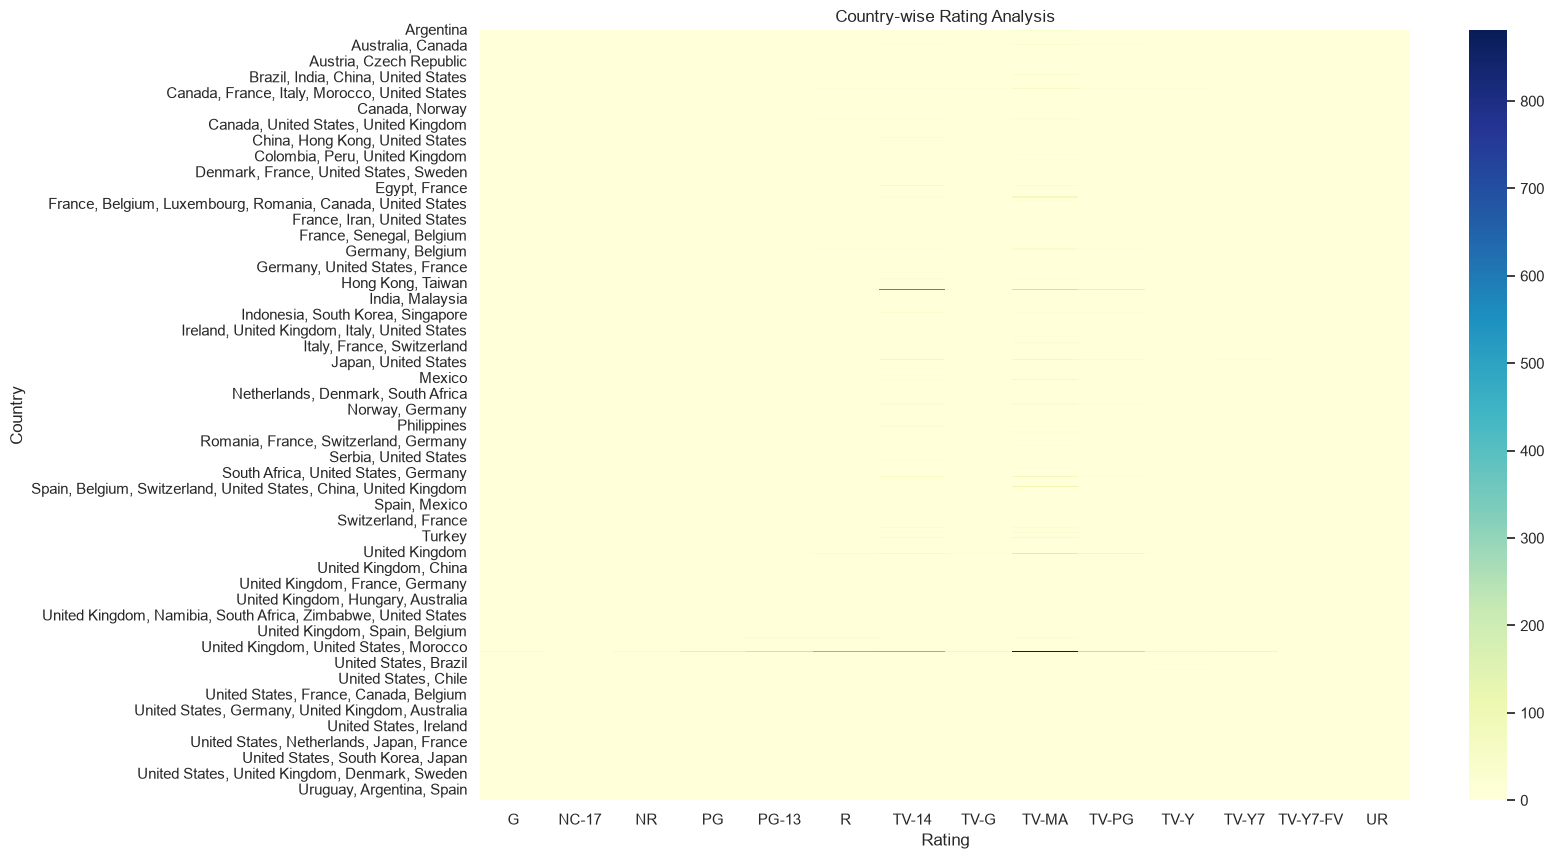

In [25]:
#17	Determine the most popular content ratings in each country.
country_rating = pd.crosstab(df["Country"], df["Rating"])
print(country_rating)
plt.figure(figsize=(15,10))
sns.heatmap(country_rating,
            cmap="YlGnBu")
plt.title("Country-wise Rating Analysis")
plt.show()

Category      Movie  TV Show
Release_Date                
2008-01-01        1        0
2008-02-04        0        1
2009-05-05        1        0
2009-11-18        1        0
2010-11-01        1        0
...             ...      ...
2021-01-12        2        1
2021-01-13        1        1
2021-01-14        2        0
2021-01-15        9        6
2021-01-16        3        0

[1497 rows x 2 columns]


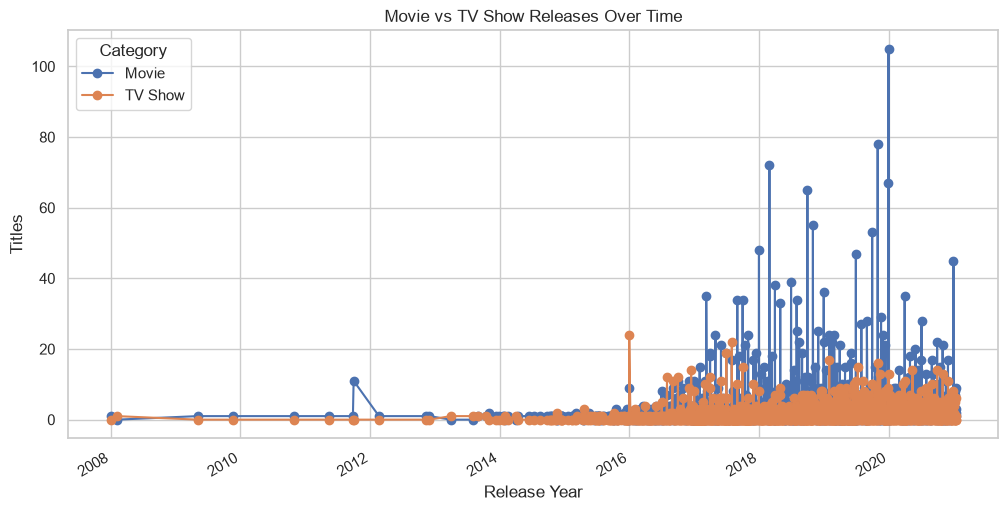

In [26]:
#18	Compare Movie and TV Show releases over time.
growth = pd.crosstab(df["Release_Date"], df["Category"])
print(growth)
growth.plot(figsize=(12,6), marker="o")
plt.title("Movie vs TV Show Releases Over Time")
plt.xlabel("Release Year")
plt.ylabel("Titles")
plt.grid(True)
plt.show()

In [23]:
#19	Identify the shortest movie available.
shortest = movies.loc[movies["Minutes"].idxmin()]
print(shortest[["Title","Minutes"]])

Title      Silent
Minutes       3.0
Name: 5606, dtype: object


Country
United States                    14
Canada                           13
India                            12
United Kingdom                   10
Canada, United States            10
Australia                        10
France                           10
United States, Canada            10
United Kingdom, United States     9
Spain                             9
Name: Rating, dtype: int64


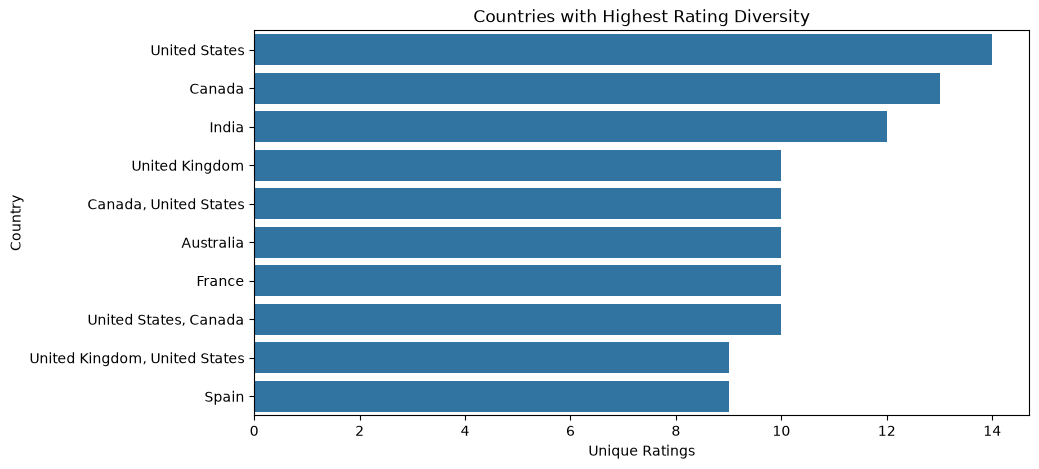

In [24]:
#20	Find the countries with the highest diversity of ratings.
rating_diversity = (
    df.groupby("Country")["Rating"]
      .nunique()
      .sort_values(ascending=False)
      .head(10)
)
print(rating_diversity)

plt.figure(figsize=(10,5))
sns.barplot(
    x=rating_diversity.values,
    y=rating_diversity.index
)
plt.title("Countries with Highest Rating Diversity")
plt.xlabel("Unique Ratings")
plt.show()

count    7789.000000
mean       17.686609
std        10.680734
min         1.000000
25%        10.000000
50%        15.000000
75%        23.000000
max       104.000000
Name: Title Length, dtype: float64


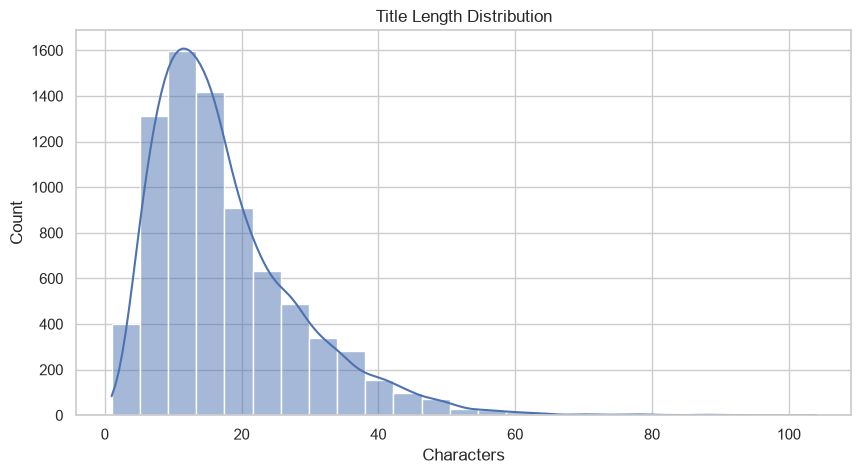

In [27]:
#21	Analyze title length (number of characters).
df["Title Length"] = df["Title"].str.len()
print(df["Title Length"].describe())
plt.figure(figsize=(10,5))
sns.histplot(
    df["Title Length"],
    bins=25,
    kde=True
)
plt.title("Title Length Distribution")
plt.xlabel("Characters")
plt.show()

Title
the          1929
of            609
a             306
in            240
and           199
to            171
&             153
love          134
my            127
2              92
for            91
with           91
i              80
on             79
christmas      77
man            71
you            70
story          65
life           59
world          59
Name: count, dtype: int64


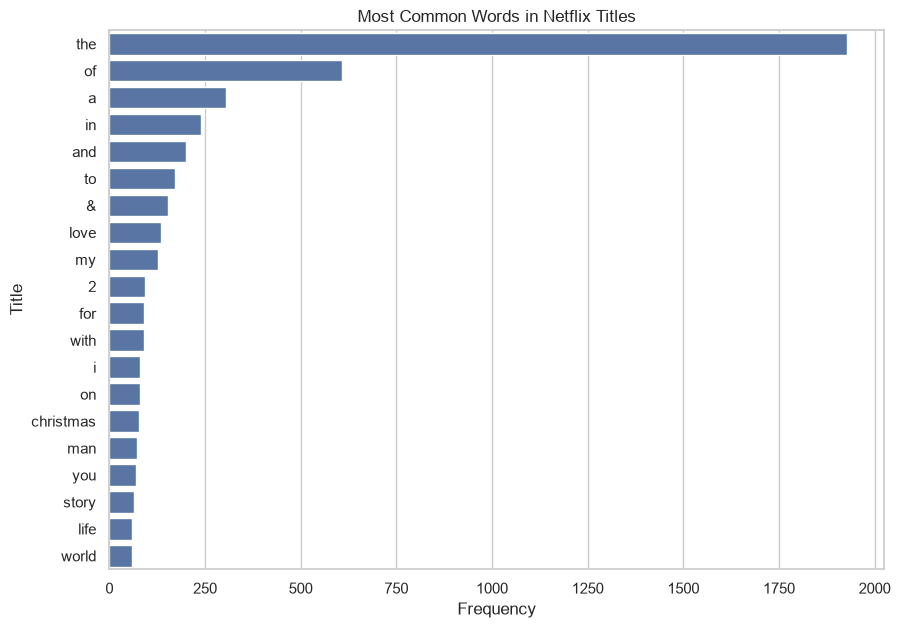

In [28]:
#22	Find the most common words used in Netflix titles.
words = (
    df["Title"]
    .str.lower()
    .str.split()
    .explode()
)
top_words = words.value_counts().head(20)
print(top_words)
plt.figure(figsize=(10,7))
sns.barplot(
    x=top_words.values,
    y=top_words.index
)
plt.title("Most Common Words in Netflix Titles")
plt.xlabel("Frequency")
plt.show()

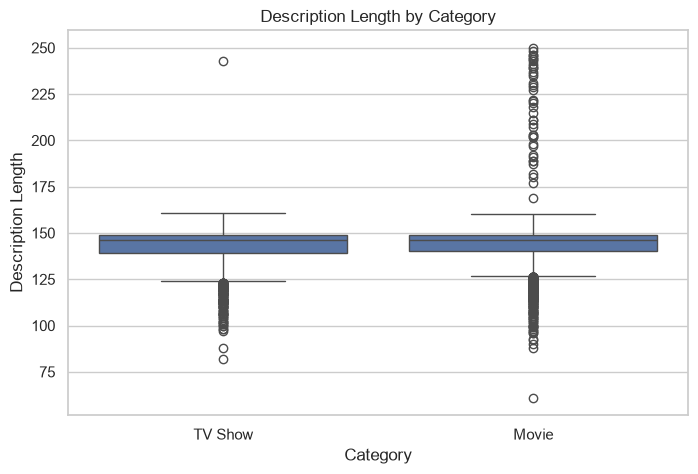

In [29]:
#23	Analyze description length for Movies vs TV Shows.
df["Description Length"] = df["Description"].str.len()
plt.figure(figsize=(8,5))
sns.boxplot(
    x="Category",
    y="Description Length",
    data=df
)
plt.title("Description Length by Category")
plt.show()

In [30]:
#24	Find duplicate titles in the dataset.
duplicate_titles = df[df["Title"].duplicated()]
print("Duplicate Titles")
print(duplicate_titles[["Title","Category"]])
print()
print("Total Duplicate Titles :", duplicate_titles.shape[0])

Duplicate Titles
                  Title Category
6300           Backfire    Movie
6622  The Lost Okoroshi    Movie

Total Duplicate Titles : 2


Category                            Movie  TV Show
Director                                          
Alessandro Angulo                       1        1
Anurag Basu                             4        1
BB Sasore                               1        1
Cosima Spender                          2        1
Dan Forrer                              1        1
Daniel Kontur                           1        1
David Ayer                              2        1
Eli Roth                                2        1
Estela Renner                           1        1
Jalil Lespert                           2        1
Jay Chandrasekhar                       1        1
Jerry Seinfeld                          1        1
Justin Webster                          1        1
Kobun Shizuno, Hiroyuki Seshita         2        1
Kyran Kelly                             1        1
Manolo Caro                             1        1
Marcus Raboy                           15        1
Mark Tonderai                  

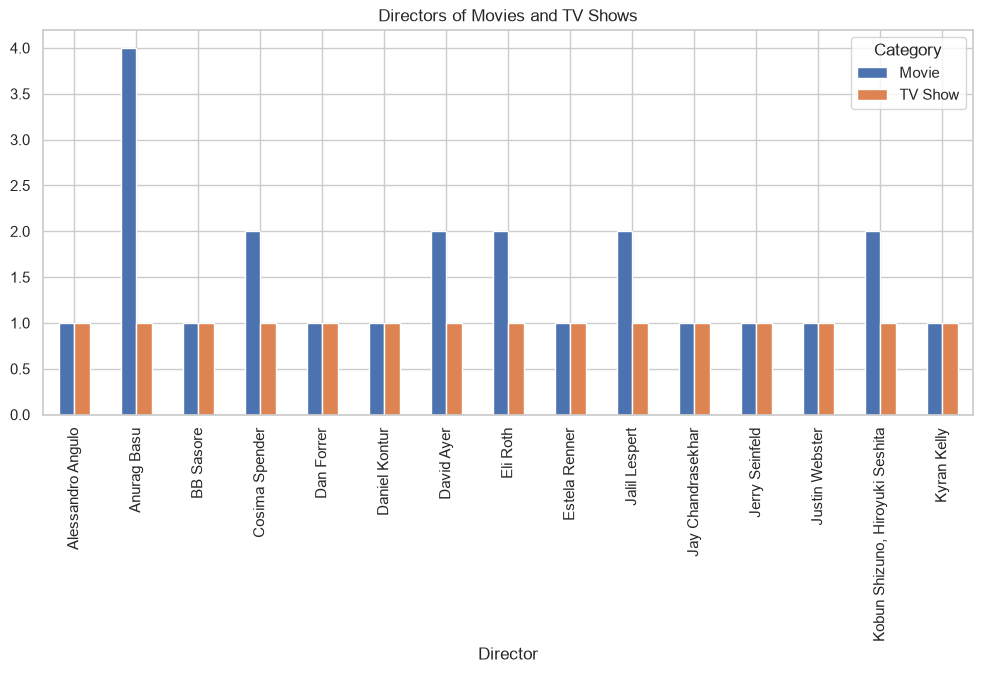

In [31]:
#25	Identify directors who have directed both Movies and TV Shows.
director_category = pd.crosstab(
    df["Director"],
    df["Category"]
)
both = director_category[
    (director_category["Movie"]>0) &
    (director_category["TV Show"]>0)
]
print(both)
both.head(15).plot(
    kind="bar",
    figsize=(12,5)
)
plt.title("Directors of Movies and TV Shows")
plt.show()

Release_Date
2012-02-21    1
2013-12-12    1
2013-12-29    1
2014-02-16    1
2014-06-15    1
             ..
2021-01-05    1
2021-01-07    1
2021-01-08    2
2021-01-10    2
2021-01-15    6
Name: count, Length: 493, dtype: int64


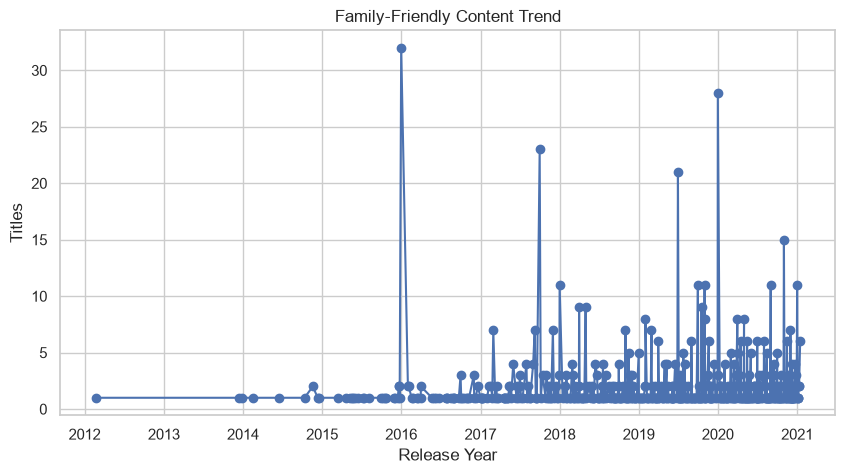

In [33]:
#26	Find the trend of family-friendly content over the years.
family = df[
    df["Rating"].isin(
        ["G","PG","TV-G","TV-Y","TV-Y7"]
    )
]
family_year = family["Release_Date"].value_counts().sort_index()
print(family_year)
plt.figure(figsize=(10,5))
plt.plot(
    family_year.index,
    family_year.values,
    marker="o"
)
plt.title("Family-Friendly Content Trend")
plt.xlabel("Release Year")
plt.ylabel("Titles")
plt.grid(True)
plt.show()

Country
United States     1246
India              230
United Kingdom     199
Spain              111
South Korea         83
Japan               82
France              77
Canada              77
Mexico              73
Turkey              50
Name: count, dtype: int64


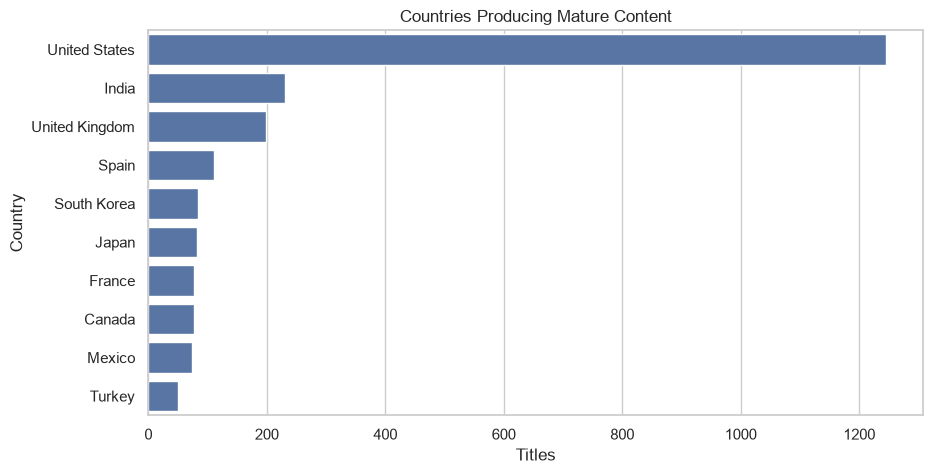

In [34]:
#27	Identify the countries contributing to mature-rated content (TV-MA, R, etc.).
mature = df[
    df["Rating"].isin(
        ["TV-MA","R","NC-17"]
    )
]
country_mature = mature["Country"].value_counts().head(10)
print(country_mature)
plt.figure(figsize=(10,5))
sns.barplot(
    x=country_mature.values,
    y=country_mature.index
)
plt.title("Countries Producing Mature Content")
plt.xlabel("Titles")
plt.show()

        NETFLIX DASHBOARD
Total Titles : 7789
Movies : 5379
TV Shows : 2410
Countries : 681
Directors : 4050
Ratings : 14
Average Movie Duration : 99.31 Minutes


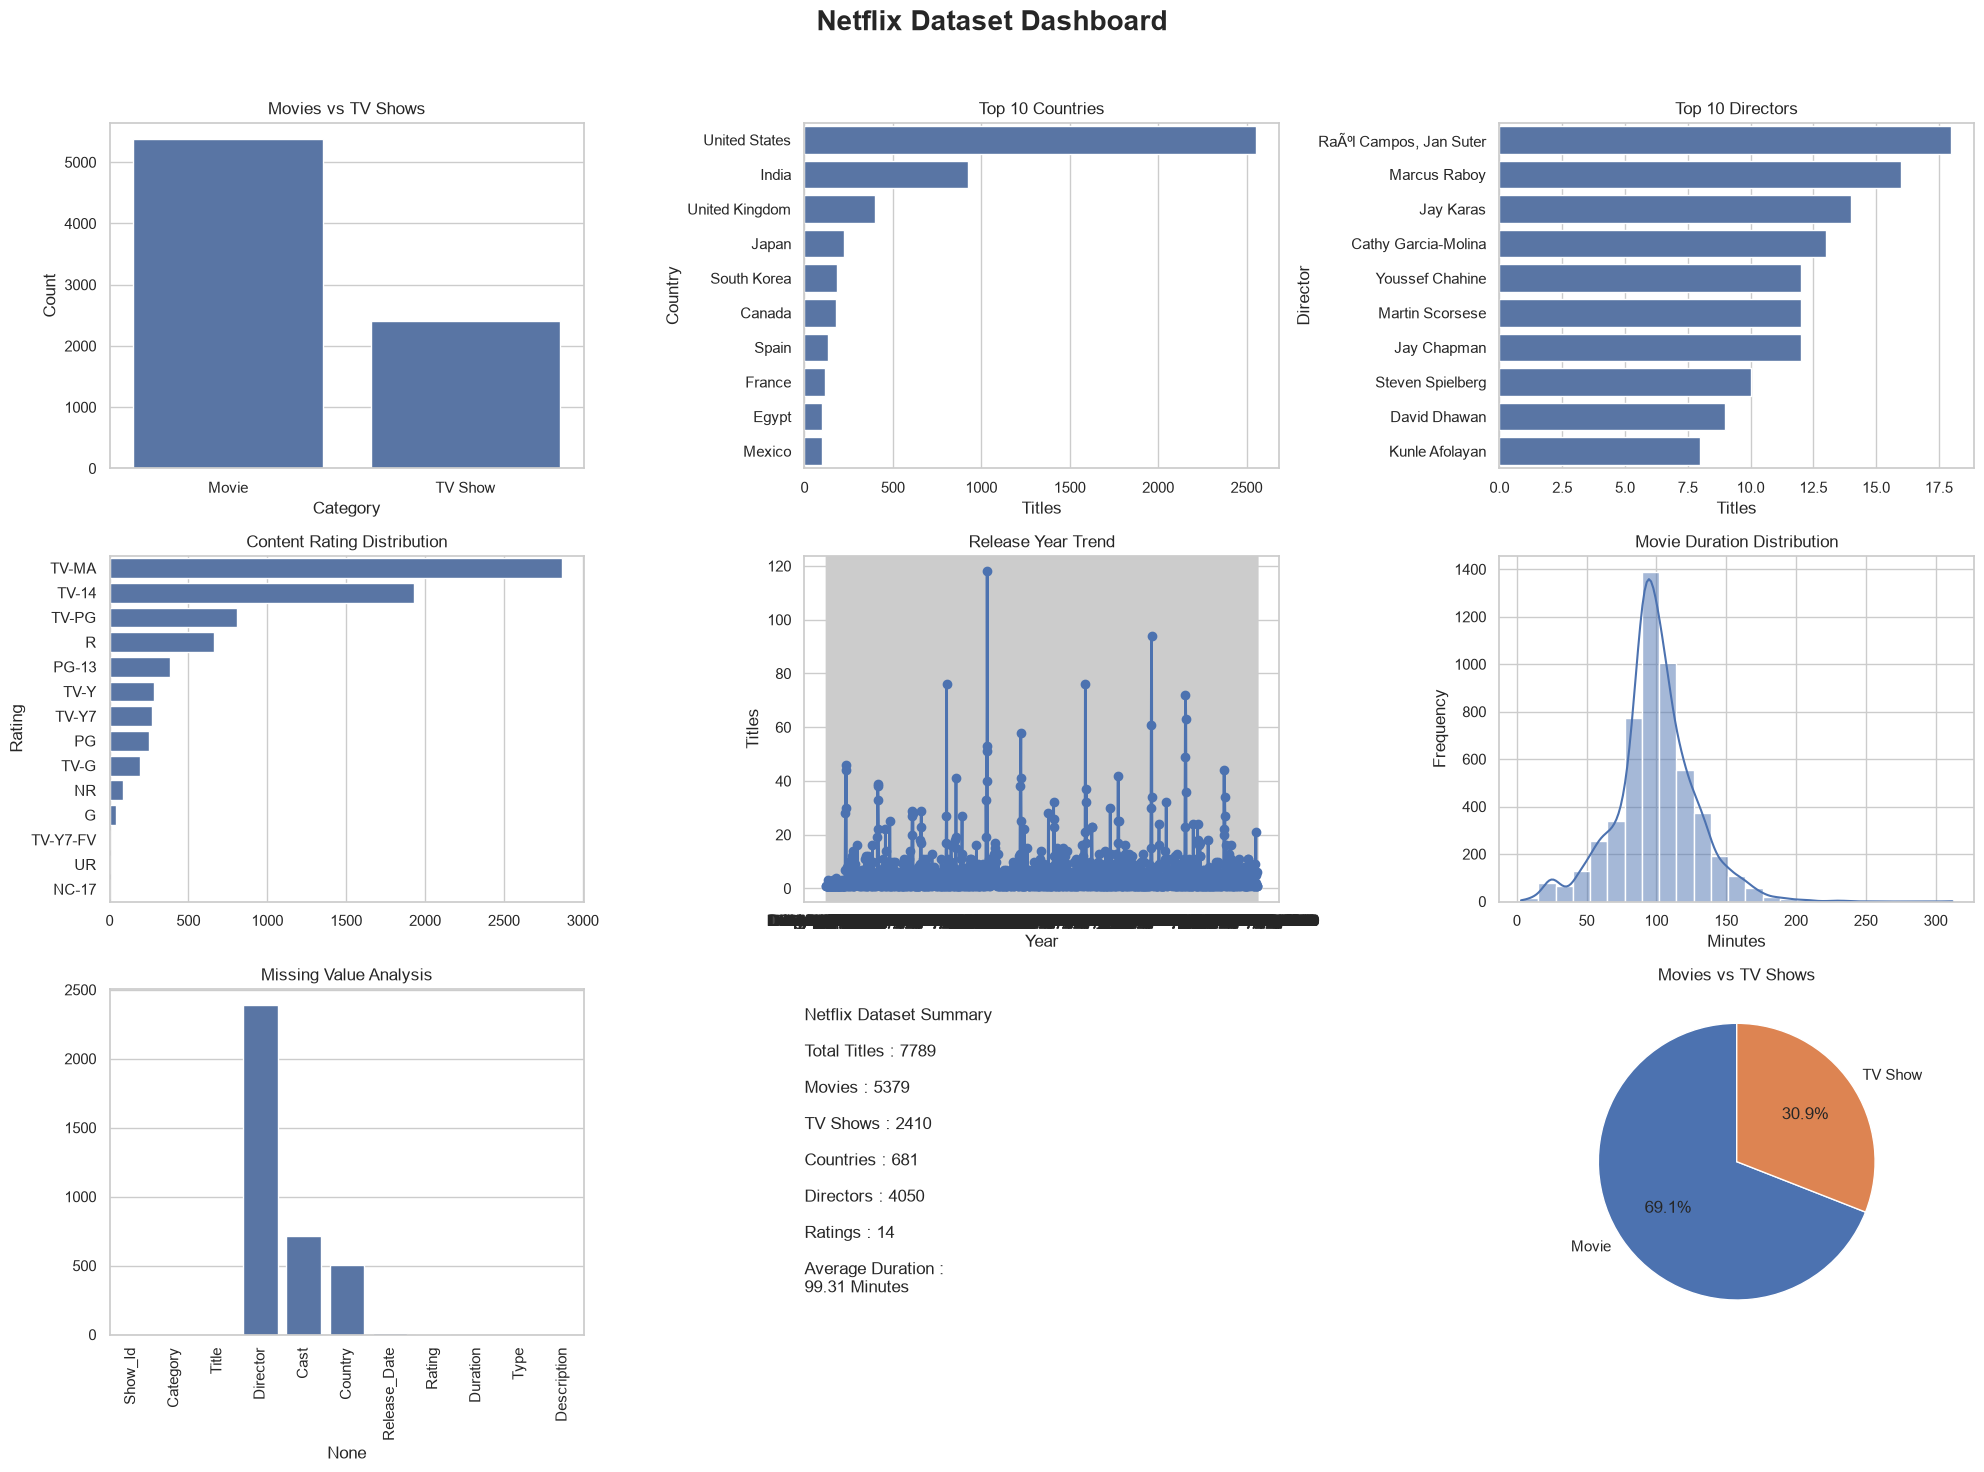

In [38]:
#28	Build a dashboard showing all major KPIs.
print("="*40)
print("        NETFLIX DASHBOARD")
print("="*40)
print("Total Titles :", len(df))
print("Movies :", (df["Category"]=="Movie").sum())
print("TV Shows :", (df["Category"]=="TV Show").sum())
print("Countries :", df["Country"].nunique())
print("Directors :", df["Director"].nunique())
print("Ratings :", df["Rating"].nunique())
print("Average Movie Duration :", round(movies["Minutes"].mean(),2),"Minutes")

# ---------------- Dashboard ----------------
# -------------------------------
fig, ax = plt.subplots(3,3,figsize=(20,15))

# ==========================================
# 1. Movies vs TV Shows
# ==========================================
category = df["Category"].value_counts()

sns.barplot(
    x=category.index,
    y=category.values,
    ax=ax[0,0]
)

ax[0,0].set_title("Movies vs TV Shows")
ax[0,0].set_xlabel("Category")
ax[0,0].set_ylabel("Count")

# ==========================================
# 2. Top Countries
# ==========================================
top_country = df["Country"].value_counts().head(10)

sns.barplot(
    x=top_country.values,
    y=top_country.index,
    ax=ax[0,1]
)

ax[0,1].set_title("Top 10 Countries")
ax[0,1].set_xlabel("Titles")
ax[0,1].set_ylabel("Country")

# ==========================================
# 3. Top Directors
# ==========================================
top_director = df["Director"].value_counts().head(10)

sns.barplot(
    x=top_director.values,
    y=top_director.index,
    ax=ax[0,2]
)

ax[0,2].set_title("Top 10 Directors")
ax[0,2].set_xlabel("Titles")
ax[0,2].set_ylabel("Director")

# ==========================================
# 4. Content Rating
# ==========================================
rating = df["Rating"].value_counts()

sns.barplot(
    x=rating.values,
    y=rating.index,
    ax=ax[1,0]
)

ax[1,0].set_title("Content Rating Distribution")

# ==========================================
# 5. Release Year Trend
# ==========================================

# Change Release_Date to Release_Year if needed
release = df["Release_Date"].value_counts().sort_index()

ax[1,1].plot(
    release.index,
    release.values,
    marker="o",
    linewidth=2
)

ax[1,1].set_title("Release Year Trend")
ax[1,1].set_xlabel("Year")
ax[1,1].set_ylabel("Titles")

# ==========================================
# 6. Movie Duration Distribution
# ==========================================
sns.histplot(
    data=movies,
    x="Minutes",
    bins=25,
    kde=True,
    ax=ax[1,2]
)

ax[1,2].set_title("Movie Duration Distribution")
ax[1,2].set_xlabel("Minutes")
ax[1,2].set_ylabel("Frequency")

# ==========================================
# 7. Missing Values
# ==========================================
missing = df.isnull().sum()

sns.barplot(
    x=missing.index,
    y=missing.values,
    ax=ax[2,0]
)
ax[2,0].tick_params(axis="x", rotation=90)
ax[2,0].set_title("Missing Value Analysis")

# ==========================================
# 8. Dataset Summary
# ==========================================
ax[2,1].axis("off")

summary = f"""
Netflix Dataset Summary

Total Titles : {len(df)}

Movies : {len(df[df['Category']=='Movie'])}

TV Shows : {len(df[df['Category']=='TV Show'])}

Countries : {df['Country'].nunique()}

Directors : {df['Director'].nunique()}

Ratings : {df['Rating'].nunique()}

Average Duration :
{movies['Minutes'].mean():.2f} Minutes
"""

ax[2,1].text(
    0,
    1,
    summary,
    fontsize=12,
    verticalalignment="top"
)
# ==========================================
# 9. Pie Chart
# ==========================================
ax[2,2].pie(
    category.values,
    labels=category.index,
    autopct="%1.1f%%",
    startangle=90
)

ax[2,2].set_title("Movies vs TV Shows")

plt.suptitle(
    "Netflix Dataset Dashboard",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout(rect=[0,0,1,0.96])

plt.show()

In [33]:
#29	Perform exploratory data analysis to discover hidden insights.
print(df.info())
print()
print(df.describe(include="all"))
print()
print(df.isnull().sum())
print()
print(df["Category"].value_counts())
print()
print(df["Rating"].value_counts())
print()
print(df["Country"].value_counts().head(10))

<class 'pandas.DataFrame'>
RangeIndex: 7789 entries, 0 to 7788
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Show_Id             7789 non-null   str  
 1   Category            7789 non-null   str  
 2   Title               7789 non-null   str  
 3   Director            5401 non-null   str  
 4   Cast                7071 non-null   str  
 5   Country             7282 non-null   str  
 6   Release_Date        7779 non-null   str  
 7   Rating              7782 non-null   str  
 8   Duration            7789 non-null   str  
 9   Type                7789 non-null   str  
 10  Description         7789 non-null   str  
 11  Title Length        7789 non-null   int64
 12  Description Length  7789 non-null   int64
dtypes: int64(2), str(11)
memory usage: 791.2 KB
None

       Show_Id Category     Title                 Director  \
count     7789     7789      7789                     5401   
unique    7787      

In [36]:
#30	Generate actionable business insights for Netflix content strategy.
print("Business Insights")
print("-----------------------------")
print("1. Focus on countries producing maximum content.")
print("2. Increase investment in top-performing directors.")
print("3. Produce more family-friendly content.")
print("4. Analyze mature-content demand by country.")
print("5. Release content consistently every year.")
print("6. Increase collaborations with popular actors.")
print("7. Improve content diversity across ratings.")
print("8. Expand production in underrepresented countries.")
print("9. Promote high-performing movie categories.")
print("10. Use viewer trends for future content strategy.")

Business Insights
-----------------------------
1. Focus on countries producing maximum content.
2. Increase investment in top-performing directors.
3. Produce more family-friendly content.
4. Analyze mature-content demand by country.
5. Release content consistently every year.
6. Increase collaborations with popular actors.
7. Improve content diversity across ratings.
8. Expand production in underrepresented countries.
9. Promote high-performing movie categories.
10. Use viewer trends for future content strategy.
